# Comprensión de datos y EDA — modelo de riesgo crediticio

Este notebook documenta el **análisis exploratorio** de `Base_de_datos.xlsx`: calidad, distribución univariable, relaciones bivariables con el pago y una mirada multivariable.

**Pregunta de negocio:** ¿qué patrones en el perfil del cliente y del crédito se asocian con pagar a tiempo (`Pago_atiempo = 1`) frente a no hacerlo (`0`)?

El objetivo aquí **no** es entrenar el modelo: es entender el dataset, detectar fugas, outliers y variables sucias **antes** del feature engineering.

## 0. Librerías y estilo de gráficos

Usamos pandas/numpy para tablas y seaborn/matplotlib para visualización. El Excel se busca subiendo carpetas desde el directorio de trabajo hasta encontrar `Base_de_datos.xlsx` (así el notebook corre tanto desde `src/` como desde la raíz del repo).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

TARGET = "Pago_atiempo"


def locate_excel(nombre: str = "Base_de_datos.xlsx") -> Path:
    """Busca el Excel en el cwd y en carpetas padre (raíz del repo)."""
    inicio = Path.cwd().resolve()
    for base in [inicio, *inicio.parents]:
        candidato = base / nombre
        if candidato.is_file():
            return candidato
    raise FileNotFoundError(
        f"No se encontró {nombre}. Corre el notebook desde el repo henry-dev-modelo-riesgo."
    )


DATA_PATH = locate_excel()
print("Archivo:", DATA_PATH)

Archivo: /Users/smerchan/Desktop/Personal/Henry/DS/Proyecto/henry-dev-modelo-riesgo/Base_de_datos.xlsx


## 1. Carga y primera mirada

Una sola hoja (`Hoja1`). Cada fila es un **préstamo**; `Pago_atiempo` es la etiqueta de cumplimiento.

In [2]:
df = pd.read_excel(DATA_PATH)
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Duplicados exactos: {df.duplicated().sum()}")
df.head()

Filas: 10,763  |  Columnas: 23
Duplicados exactos: 0


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


### Diccionario breve de variables

| Variable | Rol | Notas |
|---|---|---|
| `tipo_credito` | Categórica (código) | Producto / línea; hay un código `68` atípico |
| `fecha_prestamo` | Temporal | Originación (2024-11 a 2026-04) |
| `capital_prestado`, `plazo_meses`, `cuota_pactada` | Crédito | Monto, tenor y cuota |
| `edad_cliente`, `tipo_laboral`, `salario_cliente` | Perfil | Edad llega a 123 (revisar) |
| `total_otros_prestamos` | Endeudamiento declarado | Outliers extremos |
| `puntaje` | Score **interno** | Casi determina el target → sospecha de fuga |
| `puntaje_datacredito` | Bureau | Rango tipo score Colombia |
| `cant_creditosvigentes`, `huella_consulta` | Bureau / demanda | Huella = consultas recientes |
| `saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor` | Saldos | Nulos y ceros; mora rara |
| `creditos_sector*` | Mix de sector | Financiero / cooperativo / real |
| `promedio_ingresos_datacredito`, `tendencia_ingresos` | Ingresos bureau | ~27% nulos; tendencia mezclada con números |
| **`Pago_atiempo`** | **Target** | `1` pagó a tiempo, `0` no |

## 2. Calidad de datos: tipos, nulos y variables sucias

Revisamos dtypes, porcentaje de faltantes y valores imposibles. `tendencia_ingresos` mezcla texto (`Creciente` / `Estable` / `Decreciente`) con enteros: hay que tratarlos como inválidos.

In [3]:
calidad = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "únicos": df.nunique(dropna=False),
})
calidad.sort_values("% nulos", ascending=False)

,dtype,nulos,% nulos,únicos
tendencia_ingresos,object,2932,27.24,47
promedio_ingresos_datacredito,float64,2930,27.22,5310
saldo_mora_codeudor,float64,590,5.48,5
saldo_principal,float64,405,3.76,8648
saldo_total,float64,156,1.45,8859
saldo_mora,float64,156,1.45,56
puntaje_datacredito,float64,6,0.06,316
tipo_credito,int64,0,0.00,6
huella_consulta,int64,0,0.00,28
creditos_sectorReal,int64,0,0.00,24


In [4]:
# tendencia_ingresos: categorías válidas vs ruido numérico
TENDENCIA_OK = {"Creciente", "Decreciente", "Estable"}
tend_str = df["tendencia_ingresos"].where(
    df["tendencia_ingresos"].isin(TENDENCIA_OK)
)
print("tendencia_ingresos — tipos Python:")
print(df["tendencia_ingresos"].map(type).value_counts().to_string())
print("\nCategorías válidas vs resto:")
print(
    pd.Series(
        np.where(
            df["tendencia_ingresos"].isna(),
            "nulo",
            np.where(df["tendencia_ingresos"].isin(TENDENCIA_OK), "válida", "inválida"),
        )
    ).value_counts()
)
print("\nValores válidos:")
print(tend_str.value_counts(dropna=False))

tendencia_ingresos — tipos Python:
tendencia_ingresos
<class 'str'>      7773
<class 'float'>    2932
<class 'int'>        58

Categorías válidas vs resto:
válida      7773
nulo        2932
inválida      58
Name: count, dtype: int64

Valores válidos:
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


## 3. Variable objetivo (`Pago_atiempo`)

Clasificación **desbalanceada**: la mayoría pagó a tiempo. Accuracy sola va a verse alta aunque el modelo ignore a los morosos. En modelado conviene **Recall/F1 de la clase 0** y **AUC**, no solo accuracy.

,n,proporción
Pago_atiempo,,
0,511,0.05
1,10252,0.95


Clase mayoritaria (pago a tiempo): 95.3%  |  Clase minoritaria (no a tiempo): 4.7%


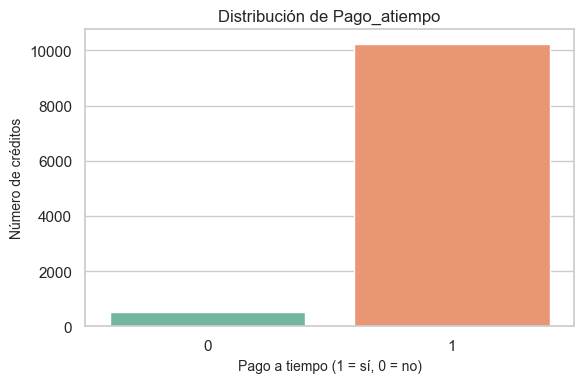

In [5]:
conteo_y = df[TARGET].value_counts().sort_index()
prop_y = df[TARGET].value_counts(normalize=True).sort_index()
resumen_y = pd.DataFrame({"n": conteo_y, "proporción": prop_y})
display(resumen_y)
print(
    f"Clase mayoritaria (pago a tiempo): {prop_y.get(1, 0):.1%}  |  "
    f"Clase minoritaria (no a tiempo): {prop_y.get(0, 0):.1%}"
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, ax=ax, hue=TARGET, palette="Set2", legend=False)
ax.set_title("Distribución de Pago_atiempo")
ax.set_xlabel("Pago a tiempo (1 = sí, 0 = no)")
ax.set_ylabel("Número de créditos")
plt.tight_layout()
plt.show()

## 4. EDA univariable — numéricas

Histogramas (escala log en montos) y un resumen estadístico. Los sesgos a la derecha y los máximos disparatados (salario en decenas de miles de millones) son candidatos a **winsorización** o a reglas de negocio (tope de ingreso).

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T.assign(nulos=df[num_cols].isna().sum())

,count,mean,std,min,25%,50%,75%,max,nulos
tipo_credito,"10,763.00",5.41,2.34,4.00,4.00,4.00,9.00,68.00,0
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","1,224,831.00","1,921,920.00","3,084,840.00","41,444,152.80",0
plazo_meses,"10,763.00",10.58,6.63,2.00,6.00,10.00,12.00,90.00,0
edad_cliente,"10,763.00",43.95,15.06,19.00,33.00,42.00,53.00,123.00,0
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"2,000,000.00","3,000,000.00","4,875,808.00","22,000,000,000.00",0
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,"500,000.00","1,000,000.00","2,000,000.00","6,787,675,263.00",0
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","121,041.50","182,863.00","287,833.50","3,816,752.00",0
puntaje,"10,763.00",91.17,16.47,-38.01,95.23,95.23,95.23,95.23,0
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,757.00,791.00,825.00,999.00,6
cant_creditosvigentes,"10,763.00",5.73,3.98,0.00,3.00,5.00,8.00,62.00,0


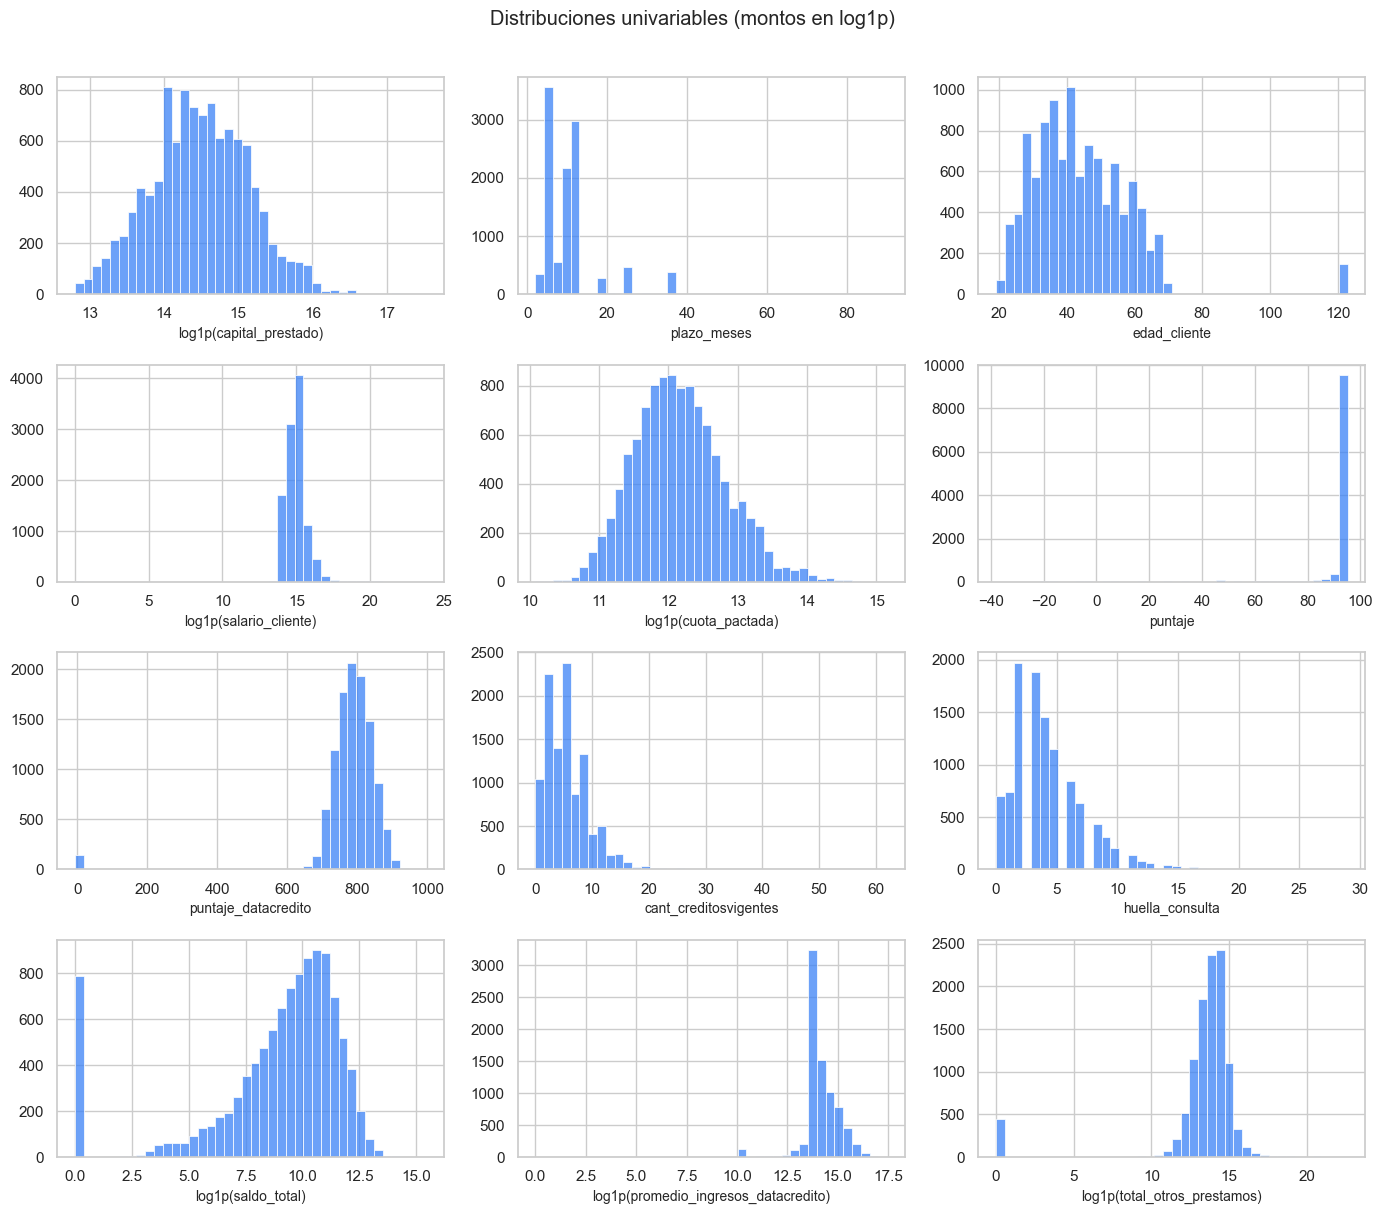

In [7]:
vars_hist = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "huella_consulta",
    "saldo_total",
    "promedio_ingresos_datacredito",
    "total_otros_prestamos",
]
log_vars = {
    "capital_prestado",
    "salario_cliente",
    "cuota_pactada",
    "saldo_total",
    "promedio_ingresos_datacredito",
    "total_otros_prestamos",
}

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
for ax, col in zip(axes.ravel(), vars_hist):
    serie = df[col].dropna()
    # Montos: log1p para ver el cuerpo de la distribución, no solo la cola
    if col in log_vars:
        sns.histplot(np.log1p(serie.clip(lower=0)), ax=ax, bins=40, color="#3b82f6")
        ax.set_xlabel(f"log1p({col})")
    else:
        sns.histplot(serie, ax=ax, bins=40, color="#3b82f6")
        ax.set_xlabel(col)
    ax.set_ylabel("")
fig.suptitle("Distribuciones univariables (montos en log1p)", y=1.01)
plt.tight_layout()
plt.show()

## 5. EDA univariable — categóricas y códigos

`tipo_credito` es un código entero (no una cantidad). `tipo_laboral` está limpio (Empleado / Independiente). `tipo_credito = 68` es un único registro: tratarlo como error o agruparlo en “otro”.

tipo_laboral


tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64


tipo_credito


tipo_credito
4     7747
6       21
7        2
9     2876
10     116
68       1
Name: count, dtype: int64


plazo_meses (tenor)


plazo_meses
2      174
3      107
4       66
5      232
6     3326
7       22
8      526
9      650
10    1520
11     324
12    2658
18     275
20      14
24     464
30      18
36     385
48       1
90       1
Name: count, dtype: int64

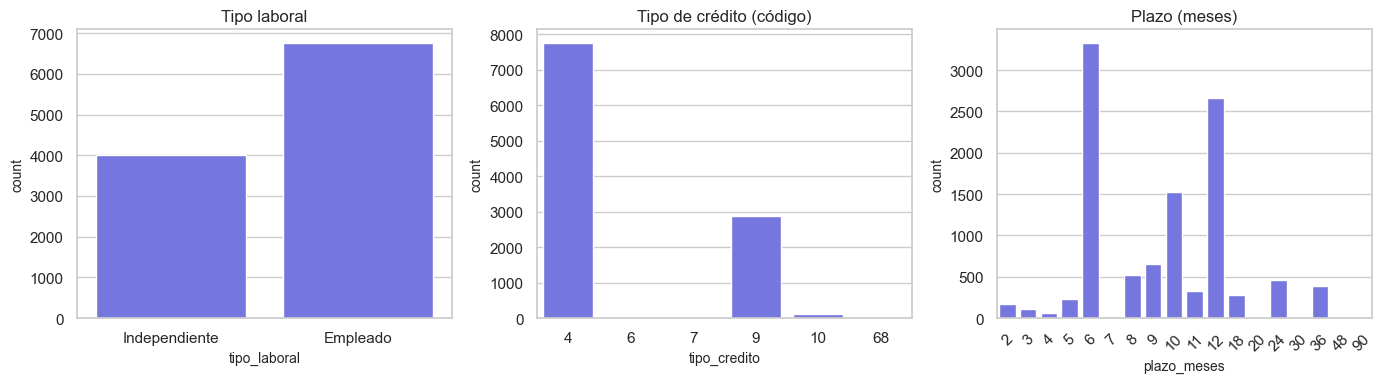

In [8]:
print("tipo_laboral")
display(df["tipo_laboral"].value_counts())
print("\ntipo_credito")
display(df["tipo_credito"].value_counts().sort_index())
print("\nplazo_meses (tenor)")
display(df["plazo_meses"].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(data=df, x="tipo_laboral", ax=axes[0], color="#6366f1")
axes[0].set_title("Tipo laboral")
sns.countplot(data=df, x="tipo_credito", ax=axes[1], color="#6366f1")
axes[1].set_title("Tipo de crédito (código)")
sns.countplot(data=df, x="plazo_meses", ax=axes[2], color="#6366f1")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_title("Plazo (meses)")
plt.tight_layout()
plt.show()

## 6. Outliers y reglas de negocio (calidad)

Banderas que hay que decidir en feature engineering: edad > 90, salario 0 o disparatado, plazos 48/90 meses (casi únicos), `puntaje` negativo, `puntaje_datacredito` negativo.

,n_filas
edad > 90,150
edad == 123,2
salario == 0,24
salario > 100M,74
otros préstamos > 100M,44
puntaje < 0,135
puntaje_datacredito < 0,1
tipo_credito == 68,1
plazo >= 48,2
saldo_mora > 0,55


Rango de fechas: 2024-11-26 09:17:04 → 2026-04-26 18:43:52


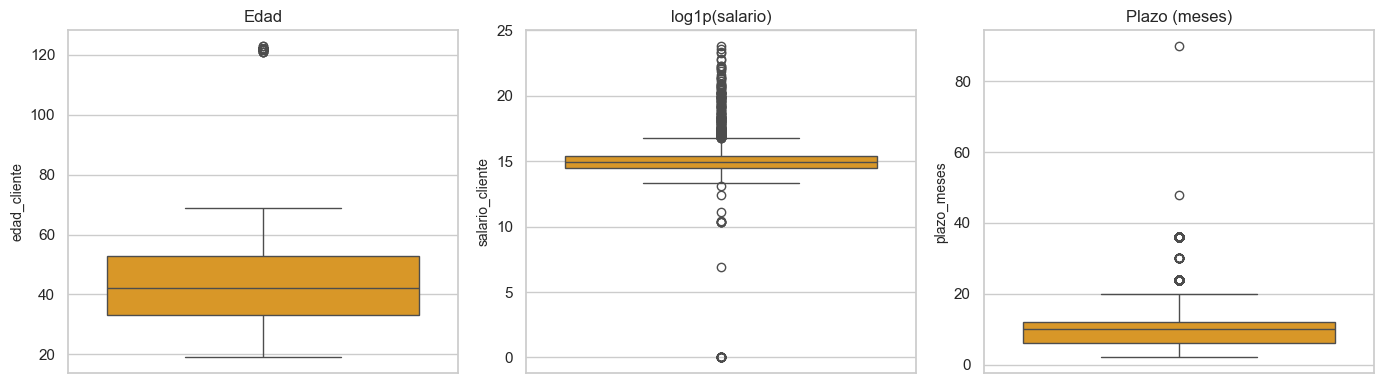

In [9]:
flags = {
    "edad > 90": (df["edad_cliente"] > 90).sum(),
    "edad == 123": (df["edad_cliente"] == 123).sum(),
    "salario == 0": (df["salario_cliente"] == 0).sum(),
    "salario > 100M": (df["salario_cliente"] > 1e8).sum(),
    "otros préstamos > 100M": (df["total_otros_prestamos"] > 1e8).sum(),
    "puntaje < 0": (df["puntaje"] < 0).sum(),
    "puntaje_datacredito < 0": (df["puntaje_datacredito"] < 0).sum(),
    "tipo_credito == 68": (df["tipo_credito"] == 68).sum(),
    "plazo >= 48": (df["plazo_meses"] >= 48).sum(),
    "saldo_mora > 0": (df["saldo_mora"].fillna(0) > 0).sum(),
}
display(pd.Series(flags, name="n_filas").to_frame())

print("Rango de fechas:", df["fecha_prestamo"].min(), "→", df["fecha_prestamo"].max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(y=df["edad_cliente"], ax=axes[0], color="#f59e0b")
axes[0].set_title("Edad")
sns.boxplot(y=np.log1p(df["salario_cliente"].clip(lower=0)), ax=axes[1], color="#f59e0b")
axes[1].set_title("log1p(salario)")
sns.boxplot(y=df["plazo_meses"], ax=axes[2], color="#f59e0b")
axes[2].set_title("Plazo (meses)")
plt.tight_layout()
plt.show()

## 7. EDA bivariable — relación con el pago a tiempo

Comparamos perfiles según `Pago_atiempo`. Independientes tienen un poco más de impago a tiempo. El plazo largo y más huella de consulta se asocian con peor cumplimiento. El **puntaje interno** lo vemos aparte (sección 8) porque no se comporta como una feature normal.

In [10]:
print("Tasa de pago a tiempo por tipo laboral")
display(
    pd.crosstab(df["tipo_laboral"], df[TARGET], normalize="index").rename(
        columns={0: "% no a tiempo", 1: "% a tiempo"}
    )
)

print("\nTasa de pago a tiempo por tipo_credito")
ct_tipo = pd.crosstab(df["tipo_credito"], df[TARGET], normalize="index")
ct_tipo["n"] = df["tipo_credito"].value_counts()
display(ct_tipo.sort_index())

print("\nTasa de pago a tiempo por tendencia válida")
tmp = df.copy()
tmp["tendencia_limpia"] = tmp["tendencia_ingresos"].where(
    tmp["tendencia_ingresos"].isin(TENDENCIA_OK), other="(nulo o inválida)"
)
ct_t = pd.crosstab(tmp["tendencia_limpia"], tmp[TARGET], normalize="index")
ct_t["n"] = tmp["tendencia_limpia"].value_counts()
display(ct_t)

Tasa de pago a tiempo por tipo laboral


Pago_atiempo,% no a tiempo,% a tiempo
tipo_laboral,,
Empleado,0.04,0.96
Independiente,0.06,0.94



Tasa de pago a tiempo por tipo_credito


Pago_atiempo,0,1,n
tipo_credito,,,
4,0.05,0.95,7747
6,0.43,0.57,21
7,0.00,1.00,2
9,0.05,0.95,2876
10,0.03,0.97,116
68,0.00,1.00,1



Tasa de pago a tiempo por tendencia válida


Pago_atiempo,0,1,n
tendencia_limpia,,,
(nulo o inválida),0.06,0.94,2990
Creciente,0.04,0.96,5294
Decreciente,0.06,0.94,1291
Estable,0.05,0.95,1188


/var/folders/v3/4blwg6fj5zb8gk5gd0wqlt2h0000gn/T/ipykernel_33992/2357843695.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=TARGET, y=col if col != "capital_prestado" else col, ax=ax, palette="Set2")
/var/folders/v3/4blwg6fj5zb8gk5gd0wqlt2h0000gn/T/ipykernel_33992/2357843695.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=TARGET, y=col if col != "capital_prestado" else col, ax=ax, palette="Set2")
/var/folders/v3/4blwg6fj5zb8gk5gd0wqlt2h0000gn/T/ipykernel_33992/2357843695.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

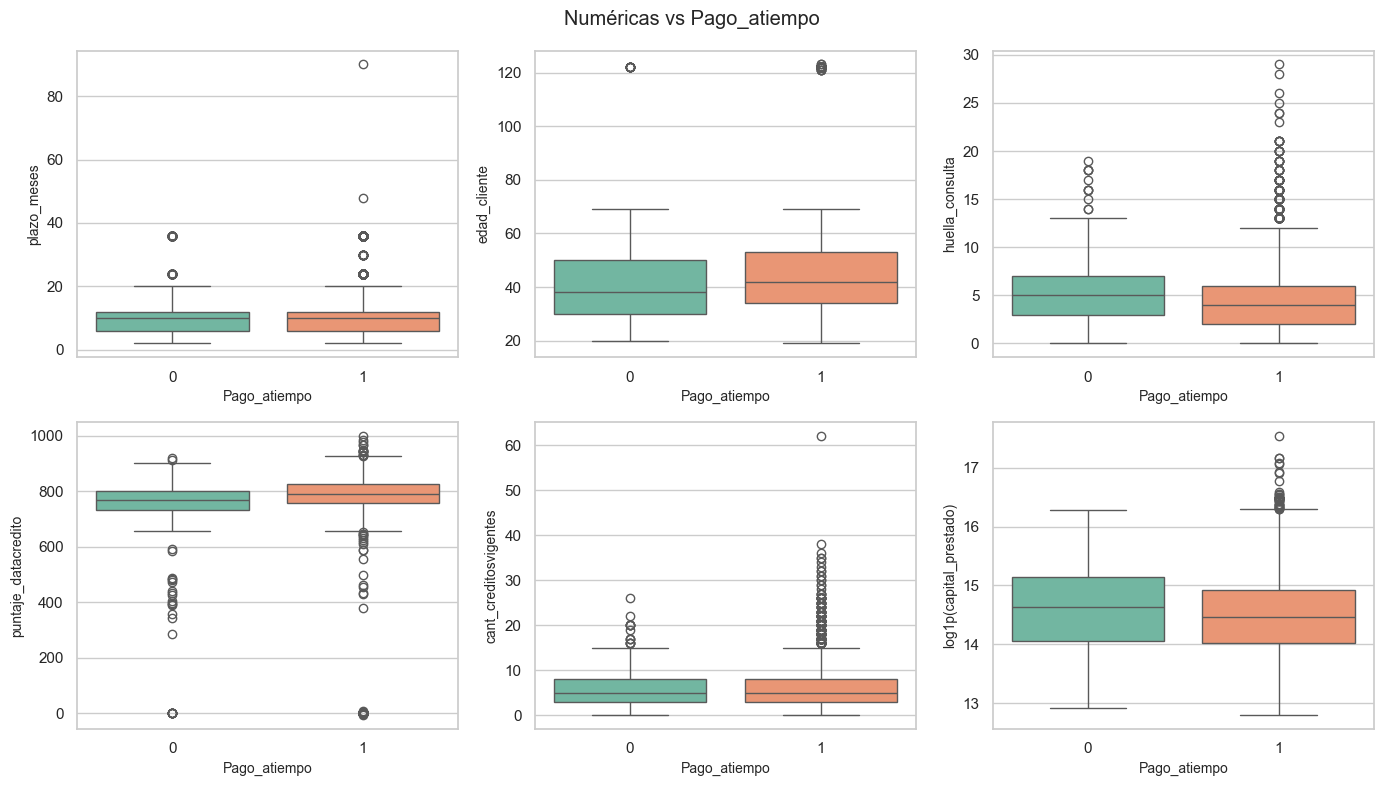

In [11]:
vars_box = [
    "plazo_meses",
    "edad_cliente",
    "huella_consulta",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "capital_prestado",
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), vars_box):
    if col == "capital_prestado":
        plot_df = df[[TARGET]].copy()
        plot_df[col] = np.log1p(df[col].clip(lower=0))
        ylab = "log1p(capital_prestado)"
    else:
        plot_df = df[[TARGET, col]]
        ylab = col
    sns.boxplot(data=plot_df, x=TARGET, y=col if col != "capital_prestado" else col, ax=ax, palette="Set2")
    ax.set_ylabel(ylab)
    ax.set_xlabel(TARGET)
fig.suptitle("Numéricas vs Pago_atiempo")
plt.tight_layout()
plt.show()

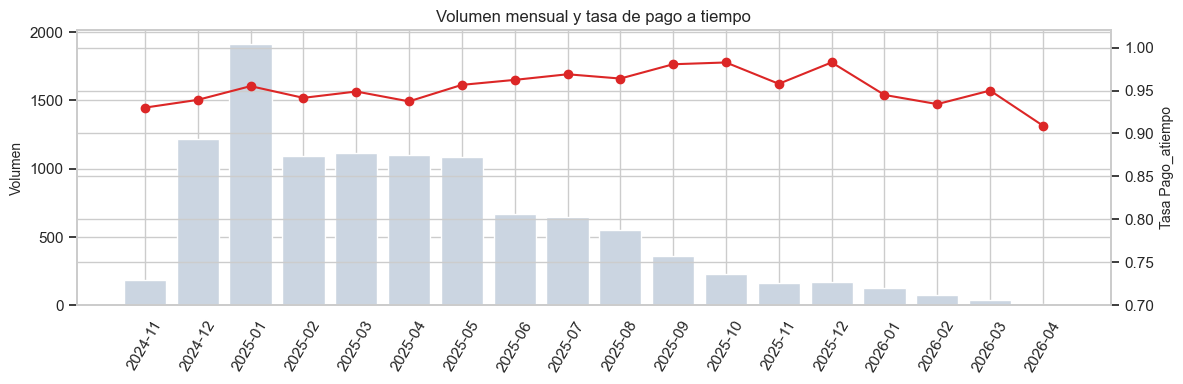

,anio_mes,n,tasa_pago
10,2025-09,361,0.98
11,2025-10,231,0.98
12,2025-11,166,0.96
13,2025-12,174,0.98
14,2026-01,127,0.94
15,2026-02,76,0.93
16,2026-03,40,0.95
17,2026-04,11,0.91


In [12]:
# Evolución temporal de originación y tasa de pago a tiempo
df_t = df.copy()
df_t["anio_mes"] = df_t["fecha_prestamo"].dt.to_period("M").astype(str)
mensual = (
    df_t.groupby("anio_mes")
    .agg(n=(TARGET, "size"), tasa_pago=(TARGET, "mean"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(mensual["anio_mes"], mensual["n"], color="#cbd5e1", label="N créditos")
ax1.set_ylabel("Volumen")
ax1.tick_params(axis="x", rotation=60)
ax2 = ax1.twinx()
ax2.plot(mensual["anio_mes"], mensual["tasa_pago"], color="#dc2626", marker="o", label="Tasa pago a tiempo")
ax2.set_ylabel("Tasa Pago_atiempo")
ax2.set_ylim(0.7, 1.02)
ax1.set_title("Volumen mensual y tasa de pago a tiempo")
fig.tight_layout()
plt.show()
display(mensual.tail(8))

## 8. Alerta de fuga: `puntaje` interno vs el target

La correlación de `puntaje` con `Pago_atiempo` es ~0.92. En la práctica **las clases no se solapan**: todo `Pago_atiempo = 0` tiene puntaje ≤ ~63 y todo `1` tiene puntaje ≥ ~64.

Eso **no** es un predictor “mágico” usable en originación: casi seguro el score interno se calcula **con información posterior** (comportamiento de pago) o es un recodificado del mismo target. Si lo metes al modelo, el AUC se infla y **no servirá en producción** para créditos nuevos.

**Recomendación:** excluir `puntaje` del entrenamiento hasta confirmar con negocio/IT *en qué momento del ciclo de vida se genera*.

                 count  mean   std    min   25%   50%   75%   max
Pago_atiempo                                                     
0               511.00 23.09 26.07 -38.01 -3.59 25.42 47.61 62.67
1            10,252.00 94.56  2.87  63.81 95.23 95.23 95.23 95.23

Separación: max(puntaje | y=0) = 62.667613 | min(puntaje | y=1) = 63.809656


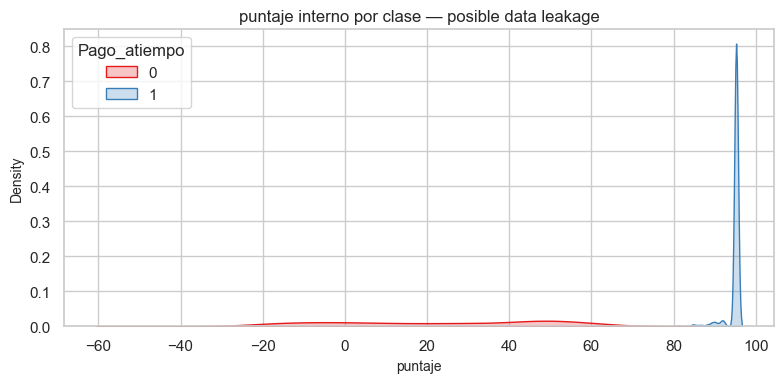


Correlación (Pearson) con Pago_atiempo:


,corr
huella_consulta,-0.07
saldo_mora,-0.07
plazo_meses,-0.06
capital_prestado,-0.04
creditos_sectorReal,-0.02
cuota_pactada,-0.01
total_otros_prestamos,-0.01
salario_cliente,-0.00
tipo_credito,0.00
saldo_mora_codeudor,0.00


In [13]:
print(df.groupby(TARGET)["puntaje"].describe())
print(
    "\nSeparación: max(puntaje | y=0) =",
    df.loc[df[TARGET] == 0, "puntaje"].max(),
    "| min(puntaje | y=1) =",
    df.loc[df[TARGET] == 1, "puntaje"].min(),
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df, x="puntaje", hue=TARGET, fill=True, common_norm=False, ax=ax, palette="Set1")
ax.set_title("puntaje interno por clase — posible data leakage")
plt.tight_layout()
plt.show()

corr_y = (
    df.select_dtypes(include=[np.number])
    .corr(numeric_only=True)[TARGET]
    .sort_values()
)
print("\nCorrelación (Pearson) con Pago_atiempo:")
display(corr_y.to_frame("corr"))

## 9. EDA multivariable

Matriz de correlación (sin `puntaje` para no dominar el mapa), ratios de capacidad de pago y un cruce tipo laboral × tendencia. Los ratios `cuota / salario` y `capital / salario` son candidatos fuertes a features: miden esfuerzo de cuota y apalancamiento, no el nivel absoluto de ingresos (distorsionado por outliers).

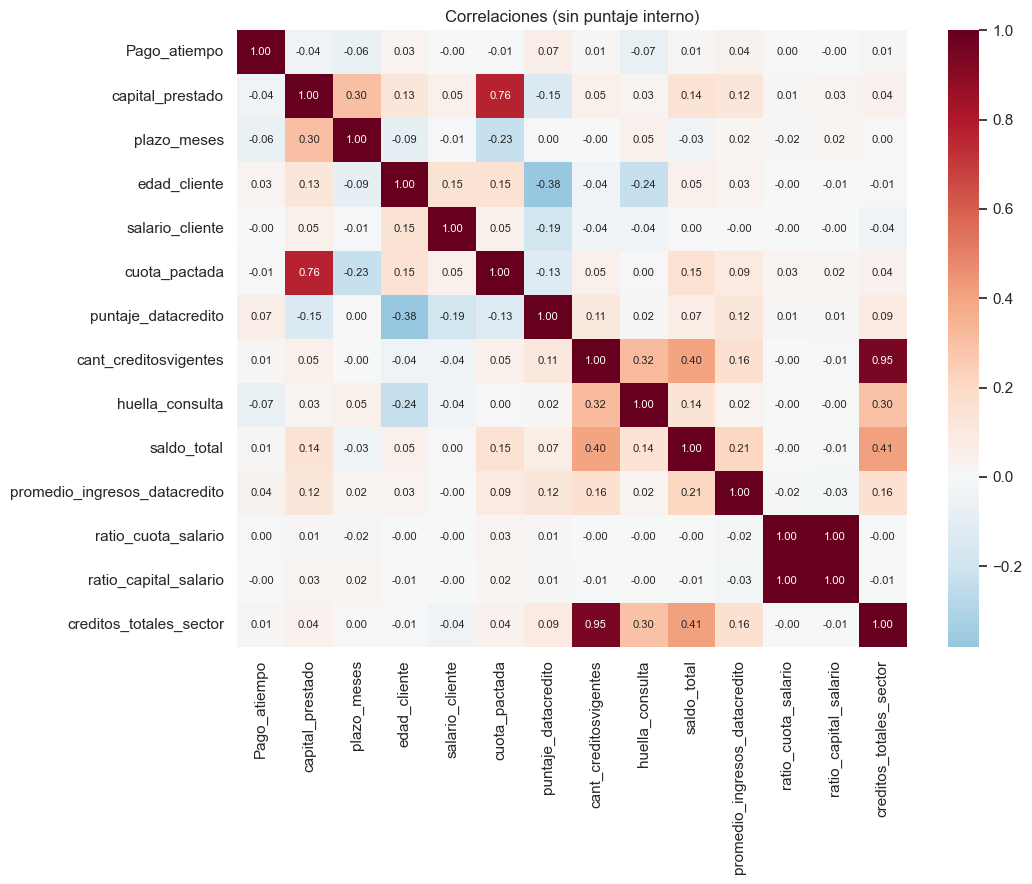

In [14]:
df_mv = df.copy()
# Ratios: salario 0 → inf; los marcamos nulos para no romper correlaciones
sal = df_mv["salario_cliente"].replace(0, np.nan)
df_mv["ratio_cuota_salario"] = df_mv["cuota_pactada"] / sal
df_mv["ratio_capital_salario"] = df_mv["capital_prestado"] / sal
df_mv["ratio_otros_salario"] = df_mv["total_otros_prestamos"] / sal
df_mv["creditos_totales_sector"] = (
    df_mv["creditos_sectorFinanciero"]
    + df_mv["creditos_sectorCooperativo"]
    + df_mv["creditos_sectorReal"]
)

cols_corr = [
    TARGET,
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "cuota_pactada",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "huella_consulta",
    "saldo_total",
    "promedio_ingresos_datacredito",
    "ratio_cuota_salario",
    "ratio_capital_salario",
    "creditos_totales_sector",
]
corr = df_mv[cols_corr].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlaciones (sin puntaje interno)")
plt.tight_layout()
plt.show()

Ratios de esfuerzo — mediana por clase


,ratio_cuota_salario,ratio_capital_salario,ratio_otros_salario
Pago_atiempo,,,
0,0.06,0.70,0.33
1,0.06,0.63,0.34


/var/folders/v3/4blwg6fj5zb8gk5gd0wqlt2h0000gn/T/ipykernel_33992/266168960.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz, x=TARGET, y="ratio_cuota_salario", ax=axes[0], palette="Set2")


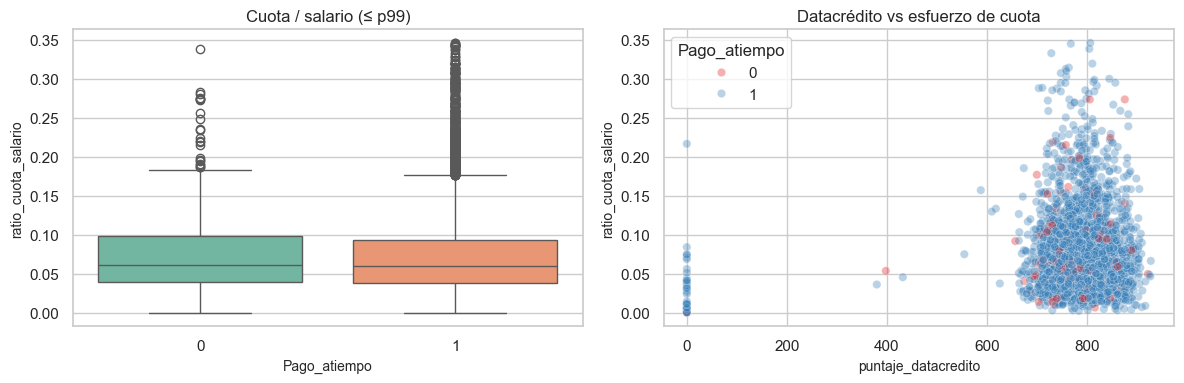


Cruce tipo_laboral × tendencia (tasa de pago a tiempo)


tendencia_limpia,(nulo/inválida),Creciente,Decreciente,Estable
tipo_laboral,,,,
Empleado,0.95,0.96,0.94,0.96
Independiente,0.94,0.95,0.93,0.95


In [15]:
print("Ratios de esfuerzo — mediana por clase")
display(
    df_mv.groupby(TARGET)[["ratio_cuota_salario", "ratio_capital_salario", "ratio_otros_salario"]].median()
)

# Recorte de cola para visualizar (p99); los extremos de salario distorsionan el eje
p99 = df_mv["ratio_cuota_salario"].quantile(0.99)
viz = df_mv[df_mv["ratio_cuota_salario"] <= p99].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=viz, x=TARGET, y="ratio_cuota_salario", ax=axes[0], palette="Set2")
axes[0].set_title("Cuota / salario (≤ p99)")
sns.scatterplot(
    data=viz.sample(min(3000, len(viz)), random_state=42),
    x="puntaje_datacredito",
    y="ratio_cuota_salario",
    hue=TARGET,
    alpha=0.35,
    ax=axes[1],
    palette="Set1",
)
axes[1].set_title("Datacrédito vs esfuerzo de cuota")
plt.tight_layout()
plt.show()

print("\nCruce tipo_laboral × tendencia (tasa de pago a tiempo)")
df_mv["tendencia_limpia"] = df_mv["tendencia_ingresos"].where(
    df_mv["tendencia_ingresos"].isin(TENDENCIA_OK), other="(nulo/inválida)"
)
display(
    df_mv.pivot_table(
        index="tipo_laboral",
        columns="tendencia_limpia",
        values=TARGET,
        aggfunc="mean",
    )
)

## 10. Hallazgos y próximos pasos (feature engineering)

**Calidad**
- 10.763 créditos, 23 columnas, **0 duplicados** exactos.
- Nulos concentrados en ingresos bureau (`promedio_ingresos_datacredito`, `tendencia_ingresos` ~27%) y en saldos (1.5%–5.5%).
- `tendencia_ingresos` tiene **58 valores numéricos** que no son categorías: hay que recodificarlos a nulo / “inválida”.
- Outliers de negocio: edad > 90, salarios de miles de millones, un `tipo_credito = 68`, plazos 48 y 90 meses.

**Target**
- ~**95.3%** pagó a tiempo vs **4.7%** que no: hay que usar métricas de clase minoritaria y, si aplica, class weights o resampling.

**Señales útiles (sin fuga)**
- `puntaje_datacredito` más alto se asocia a mejor pago (correlación débil-moderada).
- Más `huella_consulta` y plazos más largos → peor cumplimiento.
- Independientes un poco peores que empleados.
- Ratios de cuota/capital sobre salario: mejores que el salario crudo (este último está contaminado por outliers y casi no correlaciona con el target).

**No usar a ciegas**
- `puntaje` interno: **fuga / target leakage** hasta confirmar disponibilidad en originación.
- Saldos de mora actuales pueden ser **posteriores** a la decisión de crédito: validar el corte temporal con el negocio.

**Para `ft_engineering.py`**
1. Imputar nulos de bureau (indicador de “sin información” + mediana).
2. Limpiar `tendencia_ingresos` y one-hot de `tipo_laboral` / `tipo_credito` (agrupar códigos raros).
3. Winsorizar o log-transformar montos; cap de edad.
4. Crear ratios de esfuerzo y totales de créditos por sector.
5. Extraer mes/año de `fecha_prestamo` si hay estacionalidad.
6. **Split estratificado** por `Pago_atiempo` y, si el negocio lo pide, por fecha (evitar leakage temporal).